In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
33600 matching events found
No baseline correction applied


In [3]:
meta

,subject,session,run
0,1,session_0,run_0
1,1,session_0,run_0
2,1,session_0,run_0
3,1,session_0,run_0
4,1,session_0,run_0
...,...,...,...
33595,8,session_0,run_0
33596,8,session_0,run_0
33597,8,session_0,run_0
33598,8,session_0,run_0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_773/489331373.py:7: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(33600, 8, 26)

In [5]:
from hoda.hoda import BTTDA, HODA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

bttda = BTTDA(
    max_blocks=16,
    hoda_params=dict(
        rank=None,
        max_iter=256,
        tol=1e-8,
        init ='svd',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        keep_train_info=False,
        verbose=True,
        prune=False,    
    ),
    verbose=True,
    keep_train_info=True,
)
pipeline= Pipeline([
            ('bttda',bttda),
            ('vec', Vectorize()),
            ('select', SelectFwe()),
            ('zscore', StandardScaler()),
            ('lda', LinearDiscriminantAnalysis())
        ])

%lprun -f bttda.fit pipeline.fit(X,y)
bttda=pipeline['bttda']


Fitting block 1/16...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...
Initializing factors...
Fitting discriminative Tucker model...


...

  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...


Timer unit: 1e-09 s

Total time: 137.896 s
File: /project/src/hoda/hoda.py
Function: fit at line 766

Line #      Hits         Time  Per Hit   % Time  Line Contents
   766                                           
   767         1  209348914.0    2e+08      0.2      def transform(self, X, y=None, n_blocks=None):
   768         1       3474.0   3474.0      0.0          X = tl.tensor(X.copy(), dtype=X.dtype)
   769         1       6010.0   6010.0      0.0          n_samples, *_ = X.shape
   770         1       1996.0   1996.0      0.0          Xt = []
   771         6      10315.0   1719.2      0.0          if n_blocks is None:
   772         6       5053.0    842.2      0.0              n_blocks = self.n_blocks_
   773         6     270466.0  45077.7      0.0          for b in range(n_blocks):
   774         6     125026.0  20837.7      0.0              block = self.blocks_[b]
   775         6       2812.0    468.7      0.0              Xtb = block.transform(X, y)
   776         5     

In [6]:
bttda.train_info_

,mse,bic
block,,
1.0,5.510485e-11,24441.066544
2.0,5.223226e-11,24212.728564
3.0,4.943752e-11,24172.090922
4.0,4.925726e-11,24155.593696
5.0,4.918536e-11,24149.909674


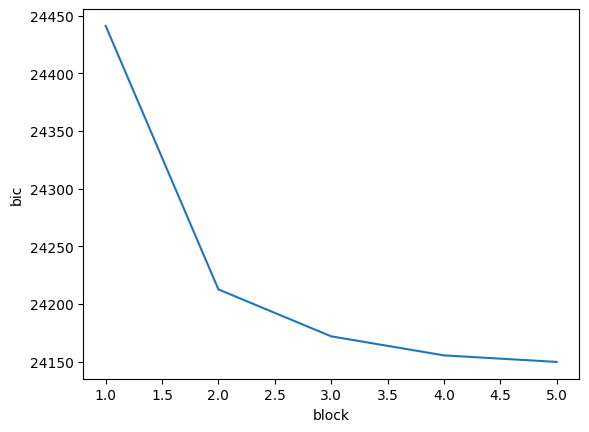

<Axes: xlabel='block', ylabel='mse'>

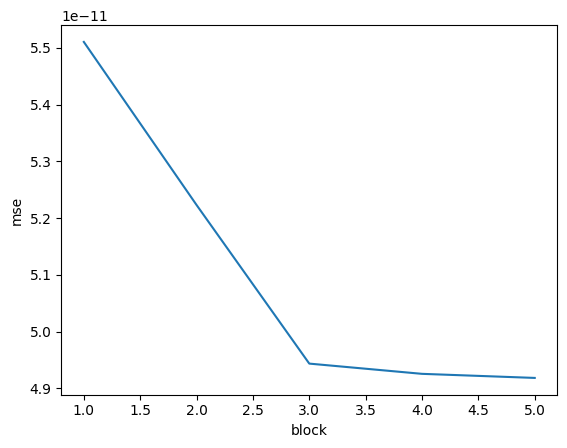

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=bttda.train_info_, x='block', y='bic')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='mse')

Not setting metadata
5600 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


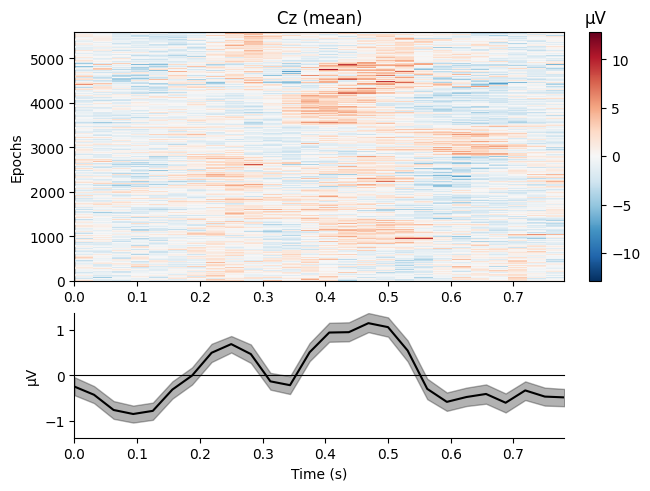

No projector specified for this dataset. Please consider the method self.add_proj.


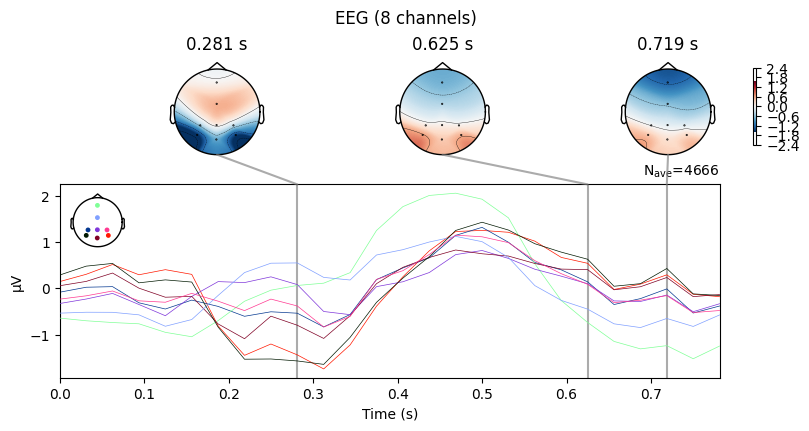

In [8]:
from mne import combine_evoked

image_args=dict(picks=['Cz'], combine='mean', sigma=8)
epochs['Target'].plot_image(**image_args)

joint_args=dict(ts_args=dict(ylim=dict(eeg=
                                       #[-50, 50]
                                       #[-2,2]
                                       None
                                      )))
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
_ = contrast.plot_joint(**joint_args)

No projector specified for this dataset. Please consider the method self.add_proj.


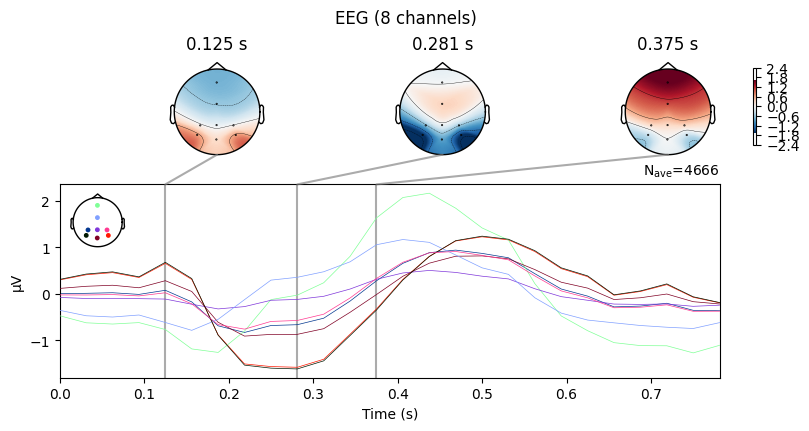

No projector specified for this dataset. Please consider the method self.add_proj.


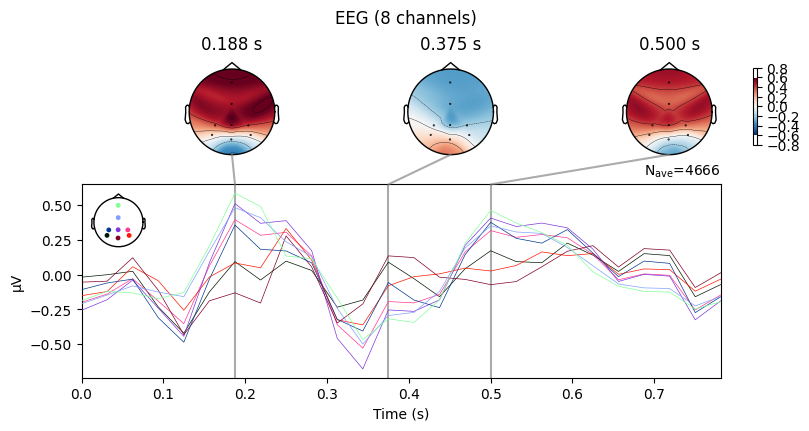

No projector specified for this dataset. Please consider the method self.add_proj.


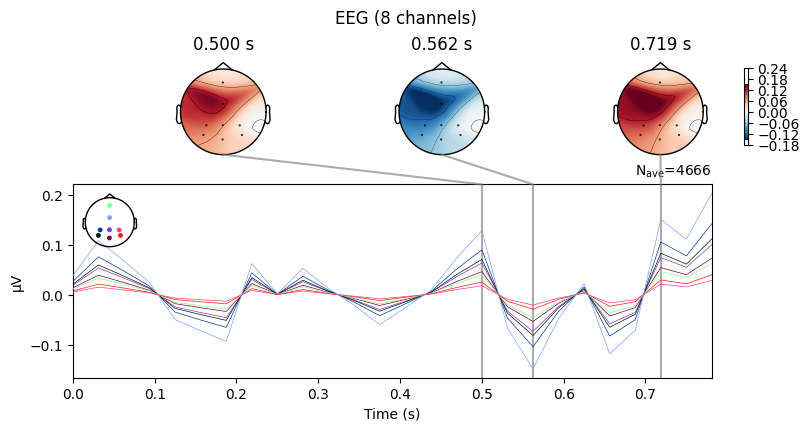

No projector specified for this dataset. Please consider the method self.add_proj.


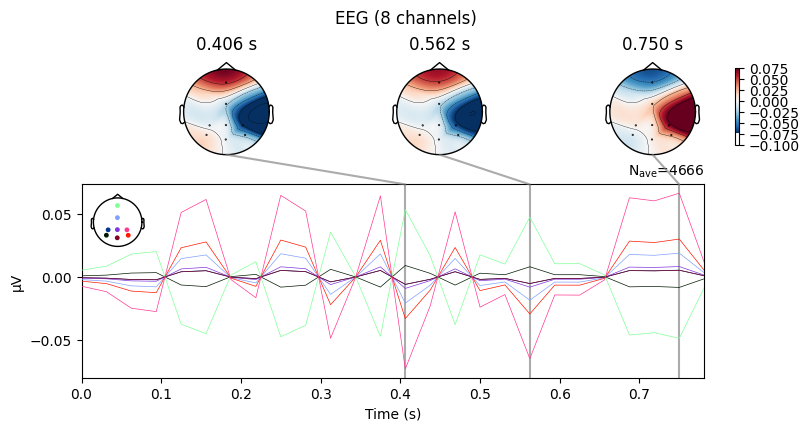

No projector specified for this dataset. Please consider the method self.add_proj.


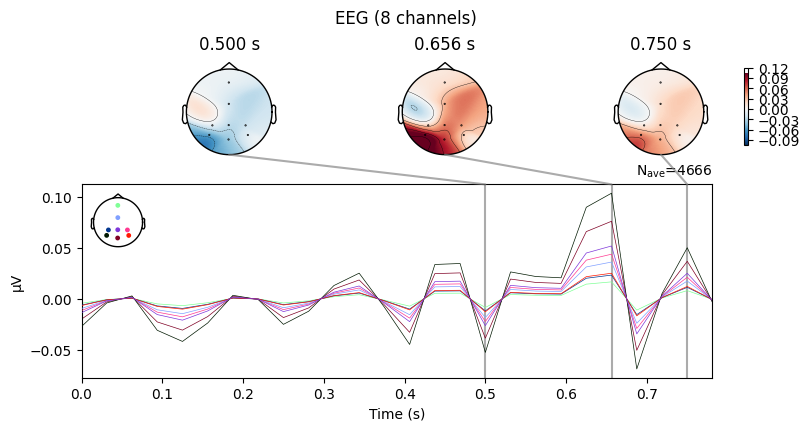

In [9]:
from mne import combine_evoked
from hoda.hoda import mse
from mne.viz import plot_compare_evokeds
import numpy as np

epochs_defl = epochs.copy()
epochs_rec = epochs.copy()
epochs_rec._data = np.zeros_like(epochs_rec.get_data())
evokeds = dict()
for b in range(len(bttda.blocks_)):
    epochs_block_rec = epochs.copy()
    epochs_block_rec._data = tl.to_numpy(bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_defl.get_data())))
    epochs_defl._data -= epochs_block_rec._data
    epochs_rec._data += epochs_block_rec._data
    
    target_block_rec = epochs_block_rec['Target'].average()
    non_target_block_rec = epochs_block_rec['NonTarget'].average()
    contrast_block_rec = combine_evoked([target_block_rec,non_target_block_rec], weights=[1,-1])
    evokeds[f'block {b}'] =contrast_block_rec
    contrast_block_rec.plot_joint(**joint_args)
    


Not setting metadata
5600 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


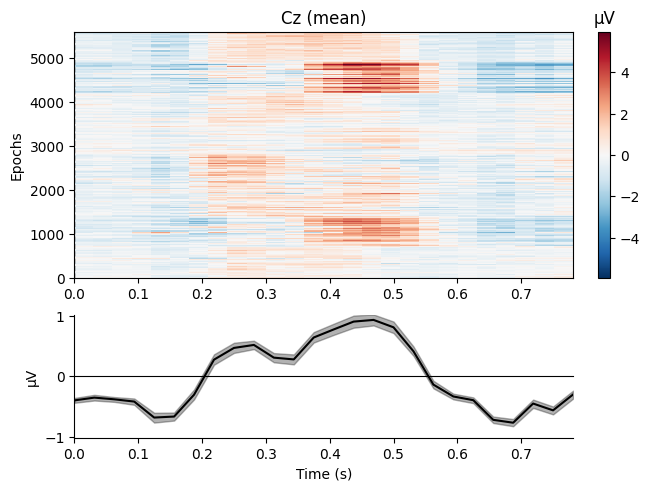

No projector specified for this dataset. Please consider the method self.add_proj.


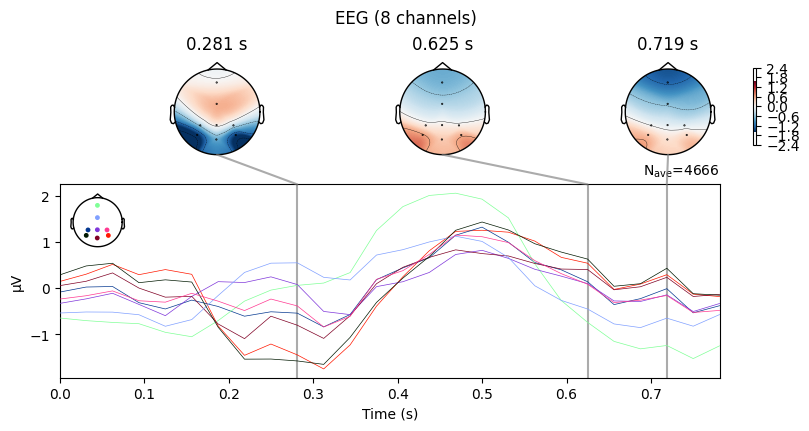

In [10]:
epochs_rec['Target'].plot_image(**image_args)
target_rec = epochs_rec['Target'].average()
non_target_rec = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target_rec,non_target_rec], weights=[1,-1])
_ = contrast_rec.plot_joint()

No projector specified for this dataset. Please consider the method self.add_proj.


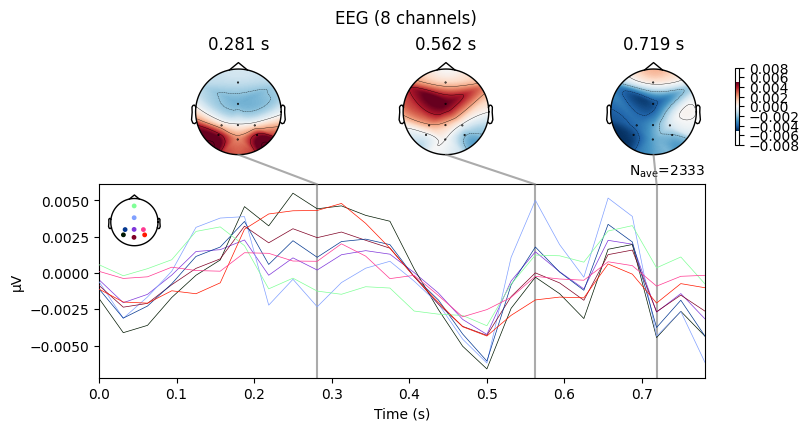

In [11]:
contrast_contrast_rec =  combine_evoked([contrast,contrast_rec], weights=[1,-1])
_ = contrast_contrast_rec.plot_joint(**joint_args)

In [12]:
Xt = bttda.transform(X)

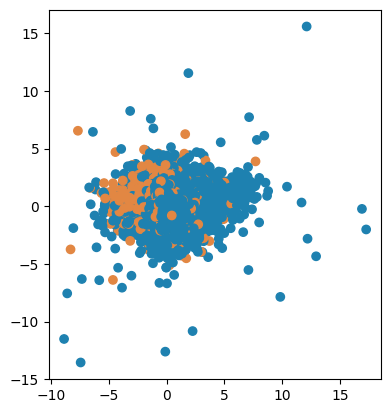

In [13]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


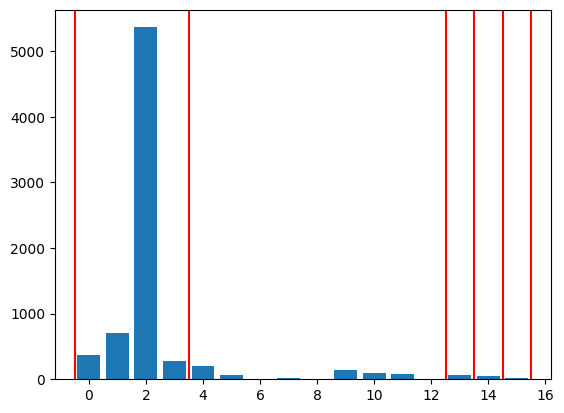

In [14]:
import scipy.stats
import seaborn as sns
import math

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
plt.bar(np.arange(len(F)),F)
n_params=0
plt.axvline(n_params-.5, color='red')
for b in bttda.blocks_:
    n_params+=math.prod(b.ml_rank_)
    plt.axvline(n_params-.5, color='red')


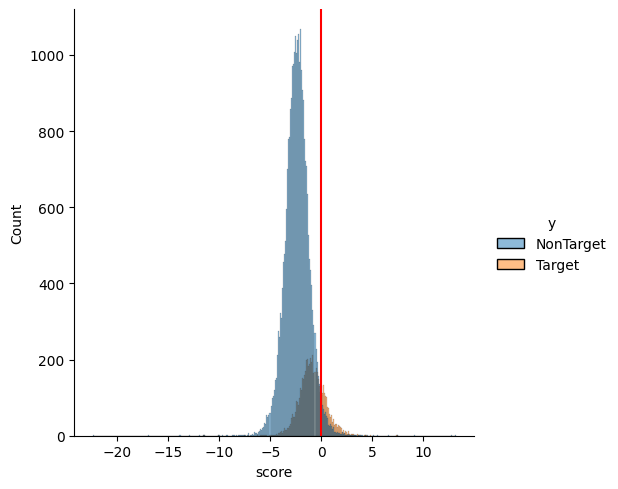

In [15]:
from sklearn.metrics import roc_auc_score
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV


score_pred = pipeline.decision_function(X)

df = pd.DataFrame(dict(score=score_pred,y=y))
g = sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
#print(gs.best_score_)
